In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Data Setup

In [2]:
# target variables: 'proctor_mdd_g_cm3', 'proctor_owc_pct'
df = pd.read_csv('./data/train.csv')
features_o = df.columns.drop(['id', 'proctor_mdd_g_cm3', 'proctor_owc_pct'])

df['clay'] = df['psd_passing_at_0_002mm_pct']
df['silt'] = df['psd_passing_at_0_063mm_pct'] - df['psd_passing_at_0_002mm_pct']
df['sand'] = df['psd_passing_at_2mm_pct'] - df['psd_passing_at_0_063mm_pct']
df['gravel'] = 100 - df['psd_passing_at_2mm_pct']
df['fine-grained'] = (df['clay'] + df['silt'] > 12)
df['ip'] = df['atterberg_liquid_limit_pct'] - df['atterberg_plastic_limit_pct']

features = df.columns.drop(['id', 'proctor_mdd_g_cm3', 'proctor_owc_pct'])

In [3]:
target = ['proctor_mdd_g_cm3', 'proctor_owc_pct']

## Correlation

### Pairwise Relationships

In [4]:
# Pearson Correlation

corr_mat = df[features].corr().round(5)
corr_mat

,psd_size_at_d10_mm,psd_size_at_d20_mm,psd_size_at_d30_mm,psd_size_at_d40_mm,psd_size_at_d50_mm,psd_size_at_d60_mm,psd_size_at_d70_mm,psd_size_at_d80_mm,psd_size_at_d90_mm,psd_size_at_d95_mm,...,hyd_cond_hyd_gradient,atterberg_liquid_limit_pct,atterberg_plastic_limit_pct,loss_on_ignition_pct,clay,silt,sand,gravel,fine-grained,ip
psd_size_at_d10_mm,1.00000,0.78159,0.68758,0.65825,0.62035,0.55870,0.49860,0.49457,0.51030,0.49970,...,-0.27113,-0.41985,-0.30393,-0.62057,-0.49730,-0.65729,0.11606,0.63143,-0.77431,-0.45886
psd_size_at_d20_mm,0.78159,1.00000,0.97603,0.88344,0.77370,0.66269,0.56438,0.51681,0.47931,0.44448,...,-0.34144,-0.51428,-0.46817,-0.68912,-0.35746,-0.45209,-0.10591,0.61235,-0.51759,-0.49157
psd_size_at_d30_mm,0.68758,0.97603,1.00000,0.94286,0.83413,0.71345,0.60496,0.54407,0.48903,0.44694,...,-0.35328,-0.53771,-0.55597,-0.64485,-0.30353,-0.37714,-0.19671,0.61342,-0.42197,-0.46509
psd_size_at_d40_mm,0.65825,0.88344,0.94286,1.00000,0.95798,0.85038,0.74331,0.67794,0.61105,0.56699,...,-0.30412,-0.50266,-0.53160,-0.48108,-0.31119,-0.38551,-0.29180,0.71168,-0.44058,-0.42603
psd_size_at_d50_mm,0.62035,0.77370,0.83413,0.95798,1.00000,0.94748,0.86112,0.80152,0.73033,0.68340,...,-0.27497,-0.45152,-0.47373,-0.36243,-0.32534,-0.40527,-0.35938,0.79644,-0.47755,-0.38549
psd_size_at_d60_mm,0.55870,0.66269,0.71345,0.85038,0.94748,1.00000,0.96761,0.91539,0.83489,0.77512,...,-0.25296,-0.32335,-0.33199,-0.33130,-0.34322,-0.43337,-0.39192,0.85708,-0.52207,-0.28141
psd_size_at_d70_mm,0.49860,0.56438,0.60496,0.74331,0.86112,0.96761,1.00000,0.97622,0.89995,0.83078,...,-0.23687,-0.10001,-0.15904,-0.31837,-0.35537,-0.44844,-0.40238,0.88402,-0.54637,-0.04559
psd_size_at_d80_mm,0.49457,0.51681,0.54407,0.67794,0.80152,0.91539,0.97622,1.00000,0.96088,0.90094,...,-0.22117,-0.04578,-0.11284,-0.31544,-0.37718,-0.46930,-0.40661,0.91355,-0.56642,0.00857
psd_size_at_d90_mm,0.51030,0.47931,0.48903,0.61105,0.73033,0.83489,0.89995,0.96088,1.00000,0.97992,...,-0.17254,-0.17987,-0.24064,-0.31992,-0.40849,-0.48459,-0.38266,0.91544,-0.56595,-0.11540
psd_size_at_d95_mm,0.49970,0.44448,0.44694,0.56699,0.68340,0.77512,0.83078,0.90094,0.97992,1.00000,...,-0.13286,-0.25077,-0.32654,-0.30671,-0.41203,-0.48336,-0.34731,0.88277,-0.54408,-0.16745


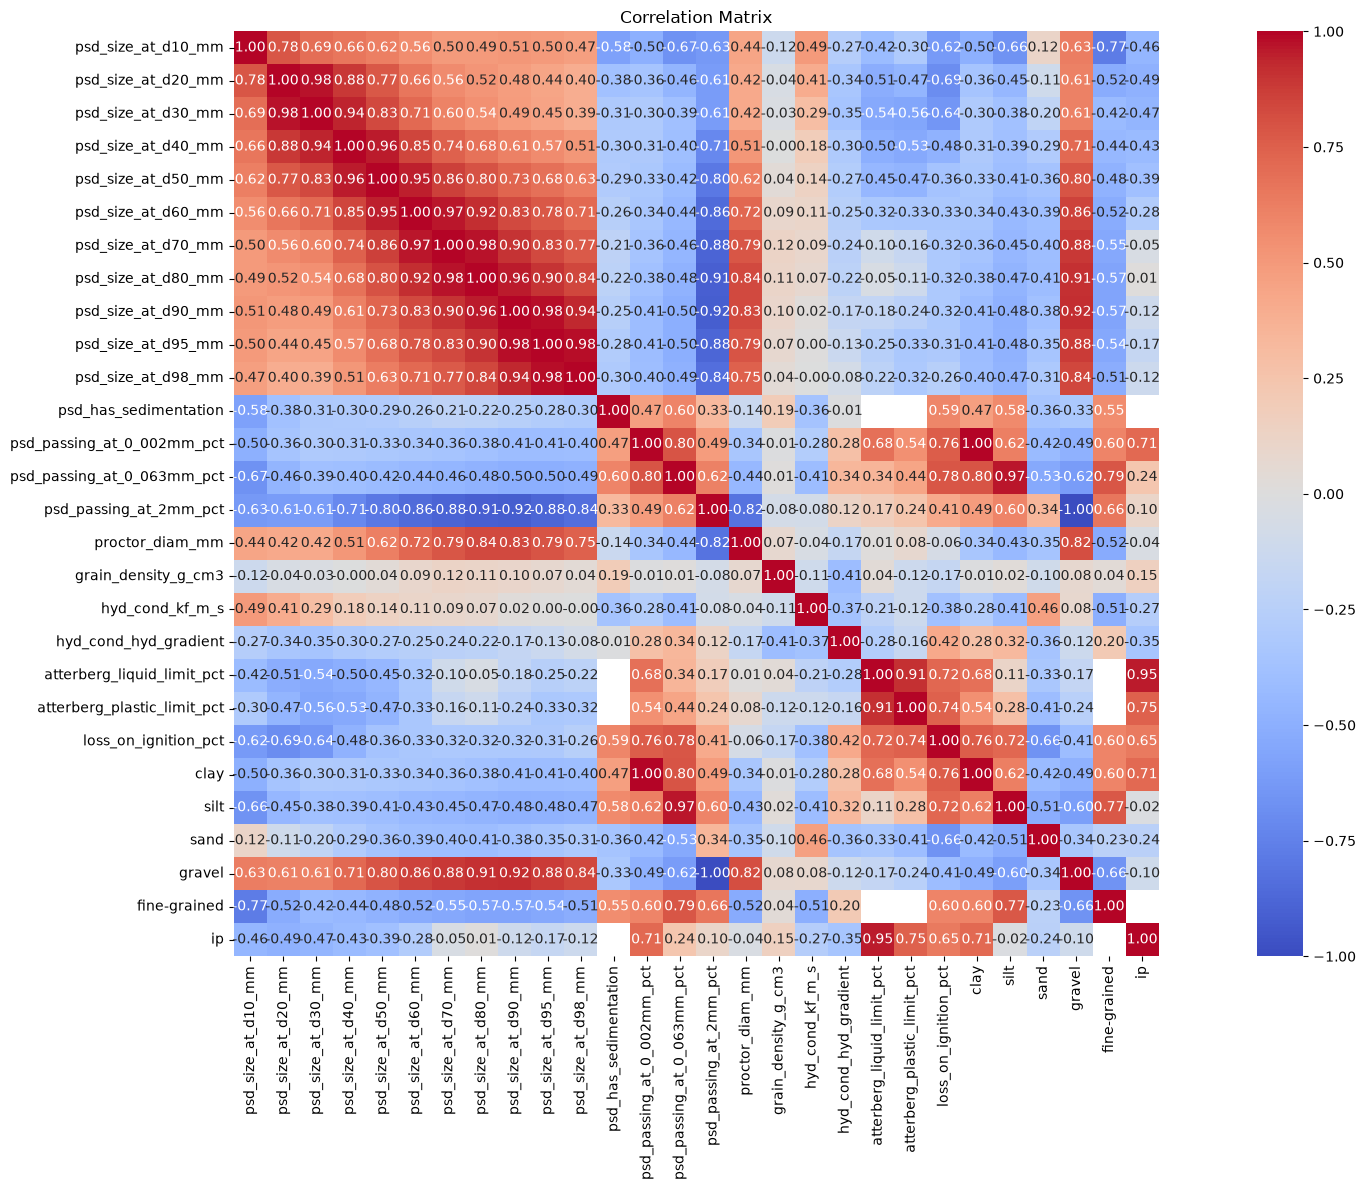

In [5]:
# Heatmap

plt.figure(figsize=(20, 12))

sns.heatmap(
    corr_mat,
    cmap='coolwarm',
    annot=True,      # Show correlation values
    fmt='.2f',       # 2 decimal places
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [6]:
# Checking for correlation value greater than 0.6

temp = ['psd_has_sedimentation', 'psd_passing_at_0_002mm_pct', 'psd_passing_at_0_063mm_pct',
       'psd_passing_at_2mm_pct', 'proctor_diam_mm', 'grain_density_g_cm3', 'hyd_cond_kf_m_s',
       'hyd_cond_hyd_gradient', 'atterberg_liquid_limit_pct', 'atterberg_plastic_limit_pct', 'loss_on_ignition_pct']

lst = []

for col in df[temp]:
    for row in df[temp]:
        if row == col:  # want upper trianglar
            break
        elif corr_mat.loc[row, col] >= 0.9:
            lst.append([row, col])

# len(lst)
lst

[['atterberg_liquid_limit_pct', 'atterberg_plastic_limit_pct']]

In [7]:
# Pearson Correlation - how strongly two variables have a linear relationship

# Features and targets
X = df[features]
y_mdd = df["proctor_mdd_g_cm3"]
y_owc = df["proctor_owc_pct"]

# Compute correlations
pearson_mdd = X.corrwith(y_mdd, method="pearson")
pearson_owc = X.corrwith(y_owc, method="pearson")

# Combine into one DataFrame
pearson_df = pd.DataFrame({
    "MDD_pearson": pearson_mdd,
    "OWC_pearson": pearson_owc
})

pearson_df

,MDD_pearson,OWC_pearson
psd_size_at_d10_mm,0.120334,-0.522984
psd_size_at_d20_mm,0.167140,-0.431503
psd_size_at_d30_mm,0.203952,-0.403329
psd_size_at_d40_mm,0.318139,-0.444758
psd_size_at_d50_mm,0.429099,-0.497086
psd_size_at_d60_mm,0.526366,-0.557734
psd_size_at_d70_mm,0.593928,-0.593852
psd_size_at_d80_mm,0.627781,-0.619294
psd_size_at_d90_mm,0.637439,-0.640556
psd_size_at_d95_mm,0.632182,-0.637250


In [8]:
# Spearman Correlation - how strongly two variables have a monotonic relationship

# Features and targets
X = df[features]
y_mdd = df["proctor_mdd_g_cm3"]
y_owc = df["proctor_owc_pct"]

# Compute correlations
spearman_mdd = X.corrwith(y_mdd, method="spearman")
spearman_owc = X.corrwith(y_owc, method="spearman")

# Combine into one DataFrame
spearman_df = pd.DataFrame({
    "MDD_spearman": spearman_mdd,
    "OWC_spearman": spearman_owc
})

spearman_df

,MDD_spearman,OWC_spearman
psd_size_at_d10_mm,0.265255,-0.631197
psd_size_at_d20_mm,0.383545,-0.692391
psd_size_at_d30_mm,0.504238,-0.753145
psd_size_at_d40_mm,0.603969,-0.798450
psd_size_at_d50_mm,0.645085,-0.817305
psd_size_at_d60_mm,0.657909,-0.818475
psd_size_at_d70_mm,0.666471,-0.805522
psd_size_at_d80_mm,0.672704,-0.790031
psd_size_at_d90_mm,0.693887,-0.784628
psd_size_at_d95_mm,0.694491,-0.758853


In [9]:
# Mutual Information - how much knowing one variable reduces your uncertainty about another variable

mi_mdd = {}
mi_owc = {}

for feature in X.columns:
    # ----- MDD -----
    temp = pd.concat([X[feature], y_mdd], axis=1).dropna()

    mi_mdd[feature] = mutual_info_regression(
        temp[[feature]],
        temp[y_mdd.name],
        random_state=42
    )[0]

    # ----- OWC -----
    temp = pd.concat([X[feature], y_owc], axis=1).dropna()

    mi_owc[feature] = mutual_info_regression(
        temp[[feature]],
        temp[y_owc.name],
        random_state=42
    )[0]

mi_df = pd.DataFrame({
    "MDD_mi": mi_mdd,
    "OWC_mi": mi_owc
})

mi_df["Max MI"] = mi_df.max(axis=1)
mi_df = mi_df.sort_values("Max MI", ascending=False)

mi_df

,MDD_mi,OWC_mi,Max MI
psd_size_at_d50_mm,0.539305,0.702167,0.702167
psd_size_at_d60_mm,0.541154,0.657052,0.657052
psd_size_at_d80_mm,0.475530,0.652114,0.652114
psd_size_at_d40_mm,0.470169,0.618400,0.618400
psd_size_at_d70_mm,0.617714,0.589566,0.617714
atterberg_plastic_limit_pct,0.597439,0.468811,0.597439
psd_size_at_d90_mm,0.499757,0.593391,0.593391
gravel,0.570493,0.565096,0.570493
psd_passing_at_2mm_pct,0.569822,0.565661,0.569822
sand,0.568420,0.527327,0.568420


In [10]:
pd.concat([pearson_df, spearman_df, mi_df], axis=1)

,MDD_pearson,OWC_pearson,MDD_spearman,OWC_spearman,MDD_mi,OWC_mi,Max MI
psd_size_at_d10_mm,0.120334,-0.522984,0.265255,-0.631197,0.268313,0.342170,0.342170
psd_size_at_d20_mm,0.167140,-0.431503,0.383545,-0.692391,0.315085,0.436343,0.436343
psd_size_at_d30_mm,0.203952,-0.403329,0.504238,-0.753145,0.368120,0.496830,0.496830
psd_size_at_d40_mm,0.318139,-0.444758,0.603969,-0.798450,0.470169,0.618400,0.618400
psd_size_at_d50_mm,0.429099,-0.497086,0.645085,-0.817305,0.539305,0.702167,0.702167
psd_size_at_d60_mm,0.526366,-0.557734,0.657909,-0.818475,0.541154,0.657052,0.657052
psd_size_at_d70_mm,0.593928,-0.593852,0.666471,-0.805522,0.617714,0.589566,0.617714
psd_size_at_d80_mm,0.627781,-0.619294,0.672704,-0.790031,0.475530,0.652114,0.652114
psd_size_at_d90_mm,0.637439,-0.640556,0.693887,-0.784628,0.499757,0.593391,0.593391
psd_size_at_d95_mm,0.632182,-0.637250,0.694491,-0.758853,0.447011,0.524211,0.524211


In [11]:
# # Heatmap

# plt.figure(figsize=(20, 15))
# sns.heatmap(
#     pd.concat([pearson_df, spearman_df, mi_df], axis=1),
#     cmap='coolwarm',
#     annot=True,      # Show correlation values
#     fmt='.2f',       # 2 decimal places
#     vmin=-1,
#     vmax=1,
#     square=True
# )

# plt.title("Pairwise Correlation")
# plt.tight_layout()
# plt.show()

### Multivariate Relationships

In [12]:
params_av = df.columns.drop(['hyd_cond_kf_m_s', 'hyd_cond_hyd_gradient', 'atterberg_liquid_limit_pct', 
                             'atterberg_plastic_limit_pct', 'loss_on_ignition_pct', 'ip', 'id', 'proctor_mdd_g_cm3', 'proctor_owc_pct'])

In [13]:
# How much of the problem is linearly explainable
# Which features still matter after accounting for all the others

model1 = LinearRegression()
model2 = LinearRegression()

X = df[params_av]
y1 = df[target[0]]
y2 = df[target[1]]

model1.fit(X, y1)
model2.fit(X, y2)

print(model1.score(X, y1))
print(model2.score(X, y2))

coef1 = pd.Series(model1.coef_, index=X.columns)
coef2 = pd.Series(model2.coef_, index=X.columns)

a = coef1.sort_values()
b = coef2.sort_values()

pd.concat([a, b], axis=1).rename(columns={0 : 'mdd', 1 : 'owc'})

0.7720059534847639
0.7952954095397633


,mdd,owc
psd_size_at_d10_mm,-0.397527,-2.216903
psd_size_at_d40_mm,-0.038228,2.475378
psd_size_at_d60_mm,-0.029684,0.551497
psd_size_at_d20_mm,-0.018930,6.107166
psd_size_at_d90_mm,-0.009952,0.082484
psd_passing_at_2mm_pct,-0.002670,0.037382
psd_passing_at_0_063mm_pct,-0.002435,0.059132
psd_passing_at_0_002mm_pct,-0.001819,0.049626
clay,-0.001819,0.049626
silt,-0.000616,0.009505


## Latent Structure

In [14]:
X = df[params_av]

# Remove targets if included
X = X.drop(columns=["proctor_mdd_g_cm3", "proctor_owc_pct"],
           errors="ignore")

X = X.fillna(X.median())

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

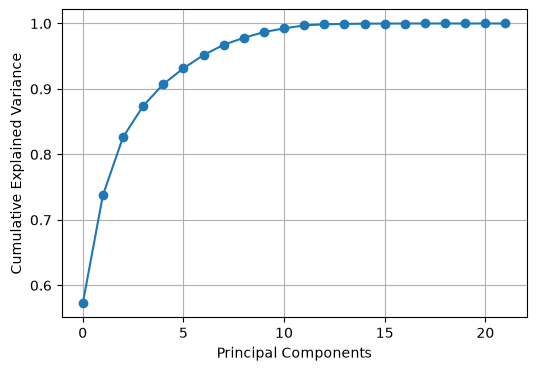

In [15]:
plt.figure(figsize=(6,4))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)

In [16]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(X.columns))],
    index=X.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22
psd_size_at_d10_mm,0.211247,0.168883,0.243772,-0.113051,0.215018,-0.029864,0.455345,-0.061315,-0.231345,0.182457,...,-0.040376,0.102033,-0.069223,-0.022685,-0.037729,0.052343,2.421751e-16,1.437828e-16,-3.300974e-17,1.341654e-16
psd_size_at_d20_mm,0.207040,0.017652,0.441960,0.088233,0.003046,0.033504,0.236110,0.224462,0.093641,0.067723,...,0.251250,-0.271935,0.390132,0.237452,0.140191,-0.325961,-9.112717e-16,-5.092718e-16,-4.573162e-16,-6.154108e-16
psd_size_at_d30_mm,0.204637,-0.043630,0.456712,0.122183,-0.073476,0.038051,0.067177,0.228782,0.121646,0.010152,...,-0.023931,0.121601,-0.339251,-0.309051,-0.199720,0.535821,1.710462e-15,9.944849e-16,5.052142e-16,8.603796e-16
psd_size_at_d40_mm,0.227354,-0.096254,0.367454,0.103879,-0.092303,-0.004034,-0.158967,0.061882,-0.003932,-0.008421,...,-0.361950,0.394051,-0.223465,0.123019,0.102481,-0.504511,-1.499208e-15,-1.100124e-15,-3.062708e-17,-3.179912e-16
psd_size_at_d50_mm,0.244181,-0.132606,0.229834,0.077282,-0.071120,-0.024411,-0.283803,-0.099644,-0.089887,0.030071,...,-0.094677,-0.258311,0.506900,0.073961,0.036317,0.414163,5.610206e-16,8.924309e-16,-2.308799e-16,9.728749e-17
psd_size_at_d60_mm,0.253712,-0.154293,0.069198,0.064017,-0.032999,0.028818,-0.334954,-0.234035,-0.132303,0.113736,...,0.446051,-0.371481,-0.310795,-0.361980,-0.161474,-0.307302,-3.517106e-16,-6.561664e-16,2.108613e-16,-3.058309e-16
psd_size_at_d70_mm,0.253512,-0.160860,-0.061757,0.043166,-0.008401,0.080533,-0.289060,-0.258705,-0.111990,0.137372,...,0.219300,0.316285,-0.158273,0.471232,0.361570,0.254742,7.694192e-16,4.679433e-17,2.106490e-16,4.937567e-16
psd_size_at_d80_mm,0.255980,-0.154012,-0.145939,-0.010016,0.005225,0.047657,-0.160608,-0.137559,-0.067919,0.116219,...,-0.318206,0.254403,0.400815,-0.152627,-0.536827,-0.129248,-6.815463e-16,6.715317e-16,-6.696034e-16,-3.393034e-16
psd_size_at_d90_mm,0.253940,-0.131463,-0.213089,-0.073963,0.002126,-0.065950,0.014015,0.153788,-0.114854,0.119254,...,-0.453615,-0.273572,-0.040811,-0.376463,0.586311,-0.008497,1.812606e-16,-1.162934e-15,7.389920e-16,1.011715e-16
psd_size_at_d95_mm,0.245520,-0.111933,-0.236170,-0.118596,-0.001235,-0.163166,0.055696,0.342561,-0.166576,0.131476,...,-0.162107,-0.363225,-0.309856,0.514210,-0.367043,0.038956,-3.284373e-17,9.397399e-16,-6.922749e-16,1.529309e-16


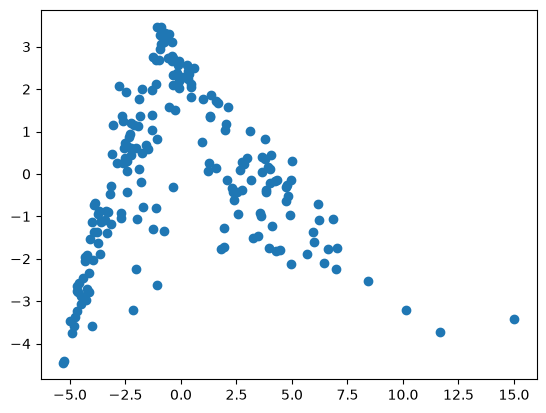

In [17]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)